In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

First, let's load a sample dataset. I'll use the `WA_Fn-UseC_-Telco-Customer-Churn.csv` file, which is a common dataset for demonstrating classification tasks. Then, we'll display the first few rows and general information about the dataset.

In [11]:
# Load the dataset
df = pd.read_csv('/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display general information about the DataFrame
print('\nGeneral information about the dataset:')
df.info()

First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



General information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pa

Next, we'll identify categorical and numerical features. We'll also check for unique values in object columns to determine if they should be treated as categorical or if they contain numerical data stored as strings (like 'TotalCharges').

In [12]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numerical columns: {numerical_cols}')
print(f'Categorical columns: {categorical_cols}')

# Check unique values for 'object' type columns that might be numerical
print("\nUnique values for object type columns (excluding 'customerID'):")
for col in categorical_cols:
    if col != 'customerID':
        print(f'{col}: {df[col].unique()}')

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Unique values for object type columns (excluding 'customerID'):
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'N

The `TotalCharges` column is of `object` type but seems to contain numerical values, with some spaces. Let's convert it to numeric, coercing errors to `NaN`, and then handle the missing values. We'll also drop the `customerID` column as it's an identifier and not useful for modeling.

In [13]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the 'customerID' column
df = df.drop('customerID', axis=1)

# Handle missing values using SimpleImputer (median for numerical columns)
# For 'TotalCharges', we'll use the median strategy.
imputer_median = SimpleImputer(strategy='median')
df['TotalCharges'] = imputer_median.fit_transform(df[['TotalCharges']])

print('\nDataFrame info after converting TotalCharges and dropping customerID:')
df.info()
print('\nMissing values after imputation:')
print(df.isnull().sum())


DataFrame info after converting TotalCharges and dropping customerID:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  

Now, let's preprocess the categorical features. For binary categorical columns (like 'gender', 'Partner', 'Dependents', etc., and the target 'Churn'), we'll use `LabelEncoder`. For multi-category nominal columns (like 'MultipleLines', 'InternetService', etc.), we'll use `OneHotEncoder`.

In [14]:
# Separate target variable first
X = df.drop('Churn', axis=1)
y = df['Churn']

# Re-identify categorical columns in X (excluding the target 'Churn')
categorical_cols_X = X.select_dtypes(include='object').columns.tolist()

# Apply LabelEncoder to binary categorical columns in X
le = LabelEncoder()
for col in categorical_cols_X:
    if X[col].nunique() == 2:
        X[col] = le.fit_transform(X[col])

# Encode the target variable y separately
y = le.fit_transform(y)

# Identify remaining categorical columns for OneHotEncoder
# These are columns with more than 2 unique values that are still 'object' type in X
multi_category_cols = X.select_dtypes(include='object').columns.tolist()

print(f'Columns to OneHotEncode: {multi_category_cols}')

# Apply OneHotEncoder to multi-category nominal columns
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_features = ohe.fit_transform(X[multi_category_cols])
ohe_feature_names = ohe.get_feature_names_out(multi_category_cols)
ohe_df = pd.DataFrame(ohe_features, columns=ohe_feature_names, index=X.index)

# Drop original multi-category columns and concatenate one-hot encoded features
X = X.drop(columns=multi_category_cols)
X = pd.concat([X, ohe_df], axis=1)

print('\nFirst 5 rows of preprocessed features (X):')
display(X.head())
print('\nFirst 5 rows of target (y):')
display(y[:5])

Columns to OneHotEncode: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

First 5 rows of preprocessed features (X):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,56.95,1889.50,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,1,53.85,108.15,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,0,42.30,1840.75,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,0,0,0,2,1,1,70.70,151.65,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0



First 5 rows of target (y):


array([0, 0, 1, 0, 1])

Finally, it's good practice to scale numerical features, especially for models sensitive to feature scales. We'll use `StandardScaler` for this.

In [15]:
# Identify numerical columns for scaling (excluding the encoded binary columns and one-hot encoded features)
# Now, numerical_cols are the original numerical columns that were not encoded.
# TotalCharges was already handled.

# Get numerical columns from X after all encoding
final_numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

# Remove any one-hot encoded columns from this list if they are mistakenly included as original numerical
# We'll consider original numerical columns from 'tenure', 'MonthlyCharges', 'TotalCharges'
# Assuming that binary encoded columns like 'gender_0', 'Partner_0' etc. are not scaled if they were already binary

# Filter for original numerical columns that need scaling
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Ensure these columns exist in X before scaling
columns_to_scale = [col for col in columns_to_scale if col in X.columns]

# Apply StandardScaler
scaler = StandardScaler()
X[columns_to_scale] = scaler.fit_transform(X[columns_to_scale])

print('\nFirst 5 rows of features (X) after scaling numerical columns:')
display(X.head())
print('\nFinal shape of features (X):', X.shape)
print('Final shape of target (y):', y.shape)


First 5 rows of features (X) after scaling numerical columns:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994242,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173244,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959674,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0,0,0,0.514251,0,0,-0.746535,-0.194766,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.940470,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0



Final shape of features (X): (7043, 40)
Final shape of target (y): (7043,)


## Churn Analysis: Model Training and Evaluation

Now that our features (`X`) and target variable (`y`) are preprocessed, we can split the data into training and testing sets. Then, we'll train a Logistic Regression model to predict customer churn and evaluate its performance.

In [23]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5634, 40)
X_test shape: (1409, 40)
y_train shape: (5634,)
y_test shape: (1409,)


We'll use Logistic Regression, a common and effective baseline for binary classification tasks, to predict churn. After training, we'll make predictions on the test set.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets and binary classification
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print('Model training complete. Predictions made on the test set.')

Model training complete. Predictions made on the test set.


Finally, let's evaluate the model's performance using a classification report, which includes precision, recall, f1-score, and support, as well as a confusion matrix.

In [25]:
# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
[[925 110]
 [164 210]]


### Visualizing Model Performance

Let's visualize the Confusion Matrix and the Classification Report metrics to get a clearer picture of the model's performance.

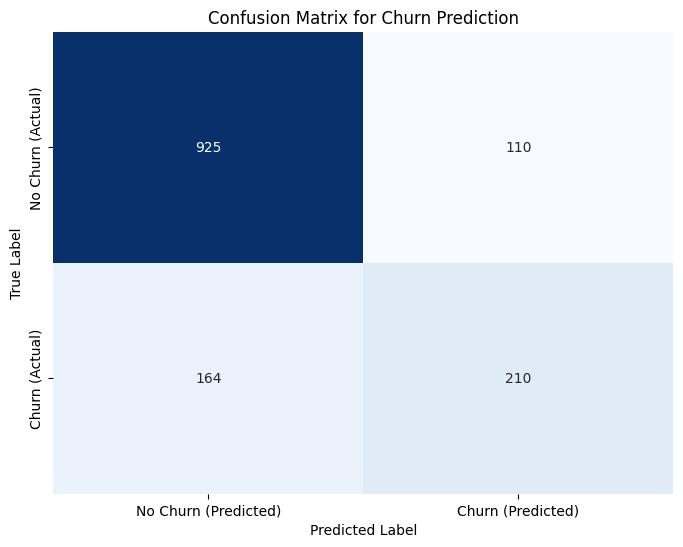

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn (Predicted)', 'Churn (Predicted)'],
            yticklabels=['No Churn (Actual)', 'Churn (Actual)'])
plt.title('Confusion Matrix for Churn Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

This heatmap of the confusion matrix clearly shows:

*   **True Negatives (Top-Left)**: Customers who did not churn and were correctly predicted as not churning.
*   **False Positives (Top-Right)**: Customers who did not churn but were incorrectly predicted as churning (Type I error).
*   **False Negatives (Bottom-Left)**: Customers who churned but were incorrectly predicted as not churning (Type II error).
*   **True Positives (Bottom-Right)**: Customers who churned and were correctly predicted as churning.

Now, let's visualize the key metrics from the classification report: Precision, Recall, and F1-Score for both classes (0: No Churn, 1: Churn).

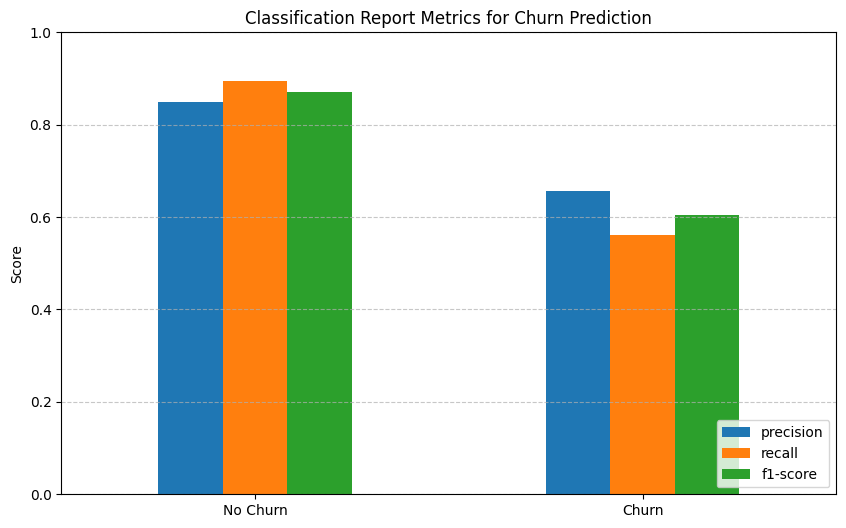

In [27]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Exclude 'accuracy', 'macro avg', 'weighted avg' for plotting individual class metrics
metrics_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]
metrics_df.index = ['No Churn', 'Churn']

metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Classification Report Metrics for Churn Prediction')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Characteristics of Customers Predicted for Long-Term Retention

To understand what defines customers likely to be retained, let's analyze the features of those predicted by our model *not* to churn (`predicted_churn == 0`).

Number of customers predicted to be retained: 1089


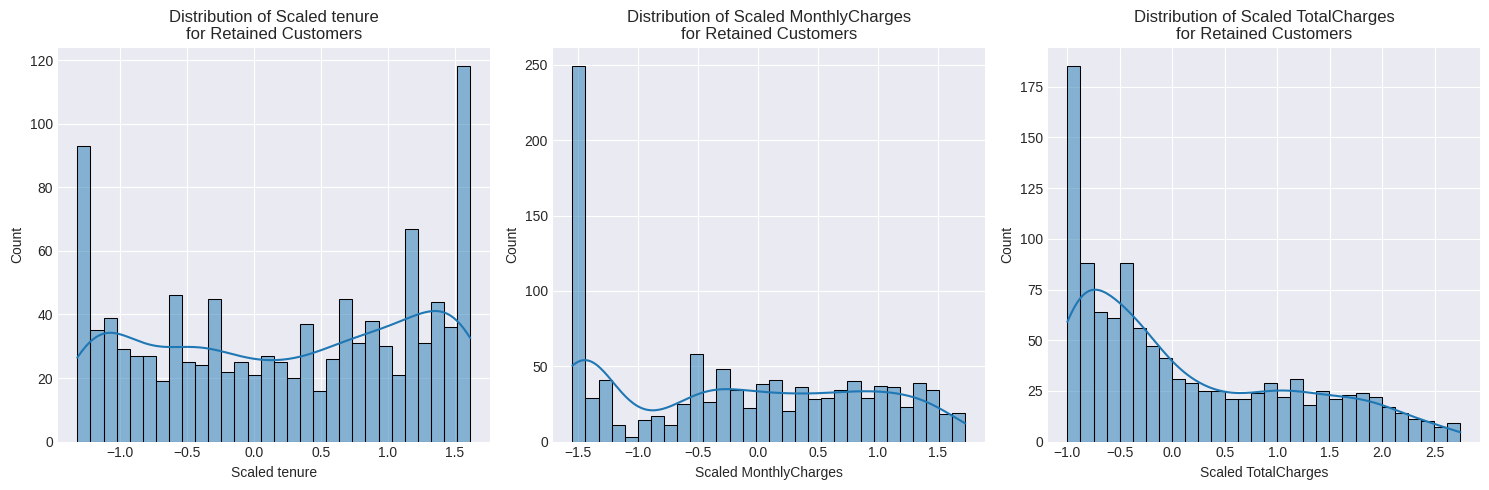

In [28]:
# Create a DataFrame for test customers with their predicted churn status
test_results_df = X_test.copy()
test_results_df['predicted_churn'] = y_pred

# Filter for customers predicted to be retained (predicted_churn == 0)
retained_customers_df = test_results_df[test_results_df['predicted_churn'] == 0]

print(f"Number of customers predicted to be retained: {len(retained_customers_df)}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid') # Set a nice style for plots

# 1. Distribution of Scaled Numerical Features for Retained Customers
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.histplot(retained_customers_df[col], kde=True, bins=30)
    plt.title(f'Distribution of Scaled {col}\nfor Retained Customers')
    plt.xlabel(f'Scaled {col}')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

From the distributions of scaled numerical features for retained customers, we can observe patterns:

*   **Tenure**: Retained customers tend to have higher (longer) tenure, with a peak towards the higher end of the scaled values.
*   **MonthlyCharges**: The distribution for monthly charges is more spread out, but there might be a tendency towards certain charge levels.
*   **TotalCharges**: Similar to tenure, retained customers seem to have accumulated higher total charges, indicating longer customer lifetimes.

Now, let's look at some important binary and multi-category features.

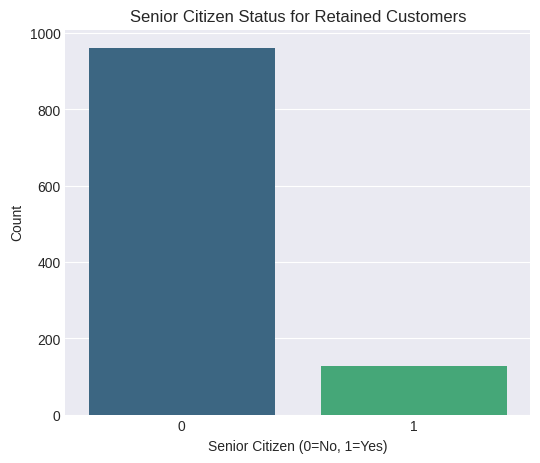

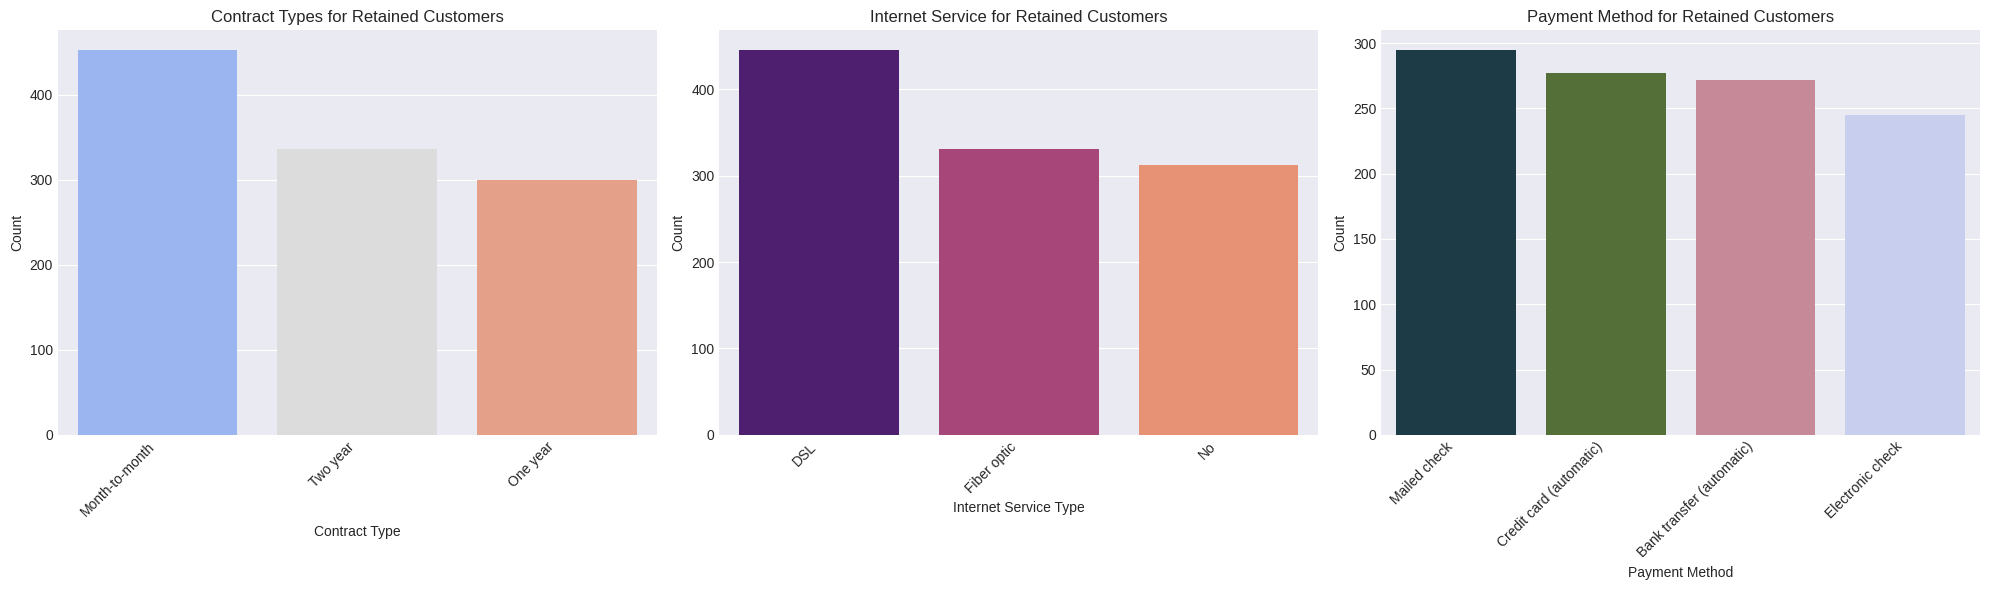

In [30]:
# Create a DataFrame for test customers with their predicted churn status
test_results_df = X_test.copy()
test_results_df['predicted_churn'] = y_pred

# Filter for customers predicted to be retained (predicted_churn == 0)
retained_customers_df = test_results_df[test_results_df['predicted_churn'] == 0]

# 2. Distribution of Binary Encoded Features (e.g., SeniorCitizen) for Retained Customers
# SeniorCitizen (0=No, 1=Yes) is directly interpretable.
plt.figure(figsize=(6, 5))
sns.countplot(x='SeniorCitizen', data=retained_customers_df, palette='viridis')
plt.title('Senior Citizen Status for Retained Customers')
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

# 3. Top Categories in One-Hot Encoded Features for Retained Customers
# We need the mapping of one-hot encoded columns back to their original feature names.
# The `ohe` object holds this information from previous steps.

ohe_feature_names = ohe.get_feature_names_out(multi_category_cols)

categorical_groups = {}
for original_col in multi_category_cols:
    categorical_groups[original_col] = [col for col in ohe_feature_names if col.startswith(f'{original_col}_')]

plt.figure(figsize=(20, 6)) # Adjust figure size for multiple subplots

# Visualize for 'Contract'
if 'Contract' in categorical_groups and categorical_groups['Contract']:
    plt.subplot(1, 3, 1)
    contract_counts = retained_customers_df[categorical_groups['Contract']].sum().sort_values(ascending=False)
    sns.barplot(x=[col.replace('Contract_', '') for col in contract_counts.index], y=contract_counts.values, palette='coolwarm')
    plt.title('Contract Types for Retained Customers')
    plt.xlabel('Contract Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

# Visualize for 'InternetService'
if 'InternetService' in categorical_groups and categorical_groups['InternetService']:
    plt.subplot(1, 3, 2)
    internet_service_counts = retained_customers_df[categorical_groups['InternetService']].sum().sort_values(ascending=False)
    sns.barplot(x=[col.replace('InternetService_', '') for col in internet_service_counts.index], y=internet_service_counts.values, palette='magma')
    plt.title('Internet Service for Retained Customers')
    plt.xlabel('Internet Service Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

# Visualize for 'PaymentMethod'
if 'PaymentMethod' in categorical_groups and categorical_groups['PaymentMethod']:
    plt.subplot(1, 3, 3)
    payment_method_counts = retained_customers_df[categorical_groups['PaymentMethod']].sum().sort_values(ascending=False)
    sns.barplot(x=[col.replace('PaymentMethod_', '') for col in payment_method_counts.index], y=payment_method_counts.values, palette='cubehelix')
    plt.title('Payment Method for Retained Customers')
    plt.xlabel('Payment Method')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Further Insights into Retained Customer Profiles

Let's continue exploring the `retained_customers_df` to uncover more consumer patterns.

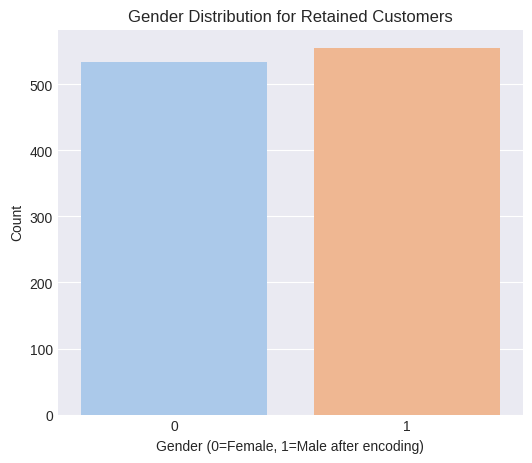

In [31]:
# Visualization 4: Gender Distribution for Retained Customers
plt.figure(figsize=(6, 5))
sns.countplot(x='gender', data=retained_customers_df, palette='pastel')
plt.title('Gender Distribution for Retained Customers')
plt.xlabel('Gender (0=Female, 1=Male after encoding)')
plt.ylabel('Count')
plt.show()

This plot shows the gender breakdown among customers predicted to be retained. If the model finds one gender more likely to stay, it could indicate underlying service preferences or marketing effectiveness.

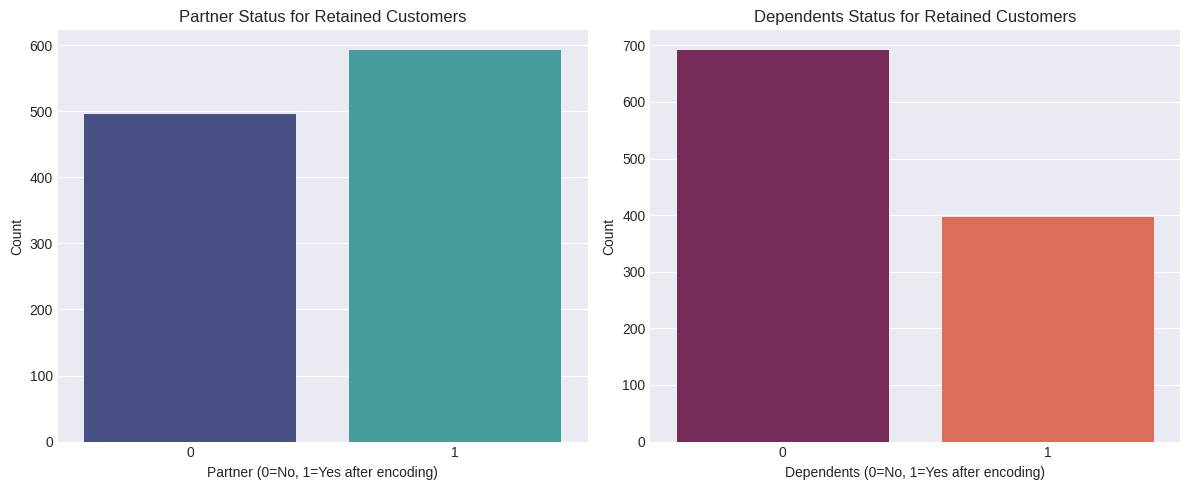

In [34]:
# Visualization 5: Partner and Dependents Status for Retained Customers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Partner', data=retained_customers_df, palette='mako')
plt.title('Partner Status for Retained Customers')
plt.xlabel('Partner (0=No, 1=Yes after encoding)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='Dependents', data=retained_customers_df, palette='rocket')
plt.title('Dependents Status for Retained Customers')
plt.xlabel('Dependents (0=No, 1=Yes after encoding)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

The Partner and Dependents plots offer insights into the household structure of long-term customers. For example, if customers with partners or dependents are more likely to be retained, it suggests family-oriented service packages or stable connections might be key.

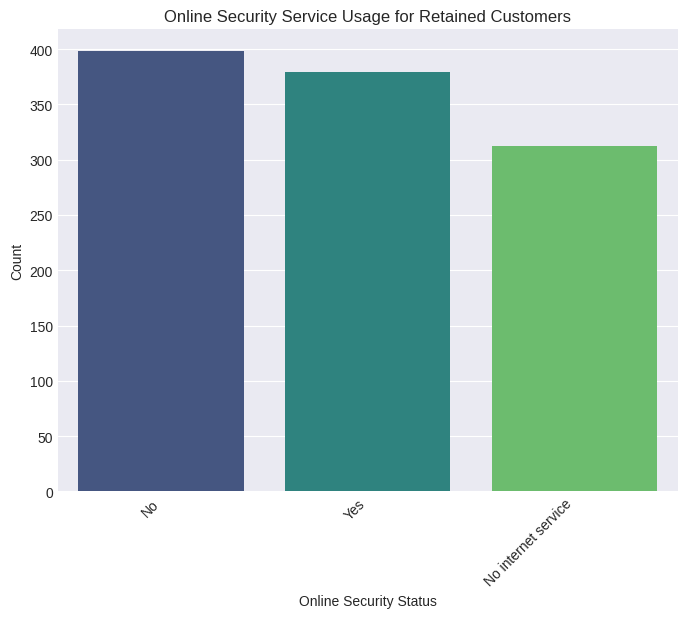

In [33]:
# Visualization 6: Online Security Service Usage for Retained Customers

# We need to map back to the original column name if 'OnlineSecurity' is one-hot encoded.
# Use the `ohe` object to get the names if it's one-hot encoded.

if 'OnlineSecurity' in categorical_groups and categorical_groups['OnlineSecurity']:
    plt.figure(figsize=(8, 6))
    online_security_counts = retained_customers_df[categorical_groups['OnlineSecurity']].sum().sort_values(ascending=False)
    sns.barplot(x=[col.replace('OnlineSecurity_', '') for col in online_security_counts.index], y=online_security_counts.values, palette='viridis')
    plt.title('Online Security Service Usage for Retained Customers')
    plt.xlabel('Online Security Status')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.show()
else:
    print("'OnlineSecurity' column not found or not multi-category in original dataset for one-hot encoding analysis.")
    # If it was binary, it's already encoded to 0/1. Let's check for that too.
    if 'OnlineSecurity' in retained_customers_df.columns:
        plt.figure(figsize=(6, 5))
        sns.countplot(x='OnlineSecurity', data=retained_customers_df, palette='viridis')
        plt.title('Online Security Service (Binary Encoded) for Retained Customers')
        plt.xlabel('Online Security (0/1)')
        plt.ylabel('Count')
        plt.show()
    else:
        print("Could not visualize 'OnlineSecurity' as it's not present in the dataframe or categorized differently.")

This visualization for Online Security shows whether customers using this service are more likely to be retained. Secure services often contribute to customer satisfaction and loyalty, making this an important feature to analyze.

### Characteristics of Customers Predicted to Churn

Now, let's analyze the features of those customers predicted by our model *to churn* (`predicted_churn == 1`). This is crucial for understanding what factors contribute to customer attrition and for developing targeted retention strategies.

Number of customers predicted to churn: 320


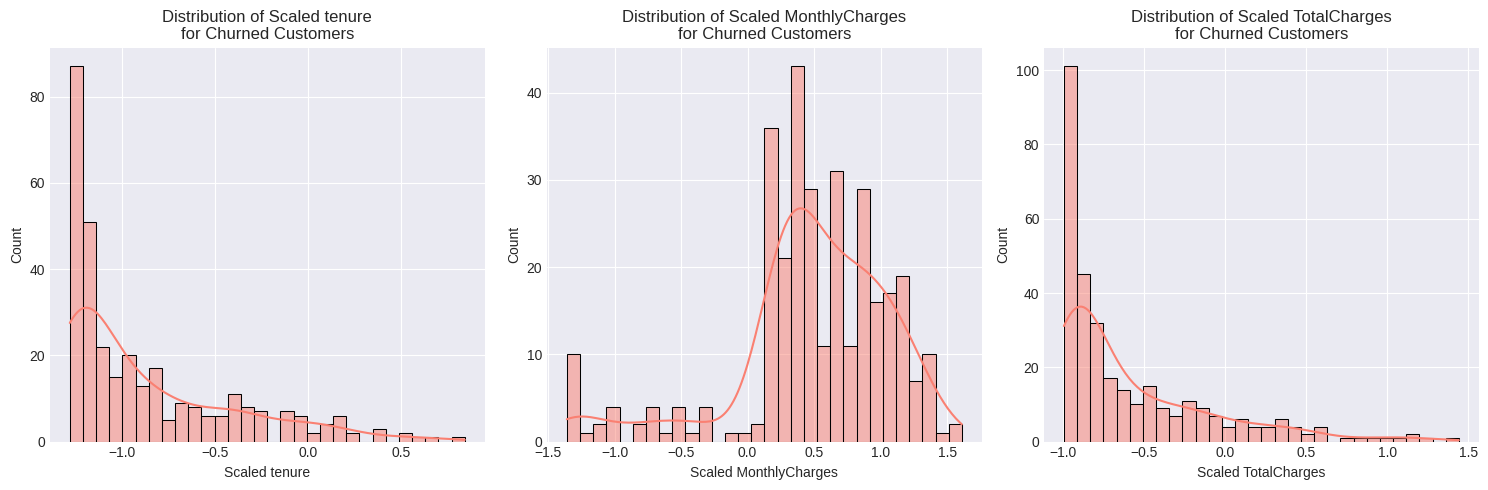

In [35]:
# Filter for customers predicted to churn (predicted_churn == 1)
churned_customers_df = test_results_df[test_results_df['predicted_churn'] == 1]

print(f"Number of customers predicted to churn: {len(churned_customers_df)}")

# Distribution of Scaled Numerical Features for Churned Customers
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.histplot(churned_customers_df[col], kde=True, bins=30, color='salmon')
    plt.title(f'Distribution of Scaled {col}\nfor Churned Customers')
    plt.xlabel(f'Scaled {col}')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

These visualizations help to profile the customers who are more likely to be retained:

*   **Senior Citizen**: We can see the proportion of senior citizens among retained customers.
*   **Contract Type**: Customers with `Two year` or `One year` contracts are often more prevalent among retained customers, indicating commitment.
*   **Internet Service**: Certain internet service types might be more associated with long-term retention than others.
*   **Payment Method**: Similarly, preferred payment methods can also indicate loyalty.